# MLP from scratch using PyTorch and autograd

In this notebook we will implement a simple Multi-Layer Perceptron (MLP) from scratch using PyTorch and its autograd functionality. The MLP will consist of an input layer, one hidden layer, and an output layer. We will train the MLP on a simple dataset to demonstrate how it works.

## Learning goals
By the end of this notebook, you should be able to:
- Build a one-hidden-layer MLP from scratch using PyTorch tensors.
- Implement ReLU and sigmoid activations and run a full forward pass.
- Implement binary cross-entropy loss and manual gradient-descent updates.
- Train with full-batch and mini-batch gradient descent and compare results.
- Visualize model behavior using a decision boundary plot.

In [1]:
import torch as t
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
t.manual_seed(0)

## Tensors
Tensors are the fundamental building blocks of PyTorch. They are similar to NumPy arrays but can also be used on GPUs for faster computation. Let's start by creating some tensors.


In [2]:
data = t.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
print(data)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])


Tensors can also be created from NumPy arrays, which is useful for interoperability between the two libraries. Here's how you can create a tensor from a NumPy array:

In [3]:
numpy_array = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
tensor_from_numpy = t.from_numpy(numpy_array)
print(tensor_from_numpy)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]], dtype=torch.float64)


You can also use PyTorch's built-in functions to create tensors filled with random values, ones, or zeros:

In [4]:
shape = (2,3,)
rand_tensor = t.rand(shape)
ones_tensor = t.ones(shape)
zeros_tensor = t.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.4963, 0.7682, 0.0885],
        [0.1320, 0.3074, 0.6341]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


Tensors can be indexed and sliced just like NumPy arrays, which makes them very flexible for data manipulation. Here's an example of how to index and slice tensors:

In [5]:
tensor = t.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


To join tensors together, you can use the `torch.cat` function, which concatenates tensors along a specified dimension. Here's how you can concatenate tensors:

In [6]:
t1 = t.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


Operations on tensors can be performed using standard arithmetic operators or using PyTorch's built-in functions. For example, you can perform matrix multiplication using the `@` operator or the `torch.matmul` function:

In [7]:
# This computes the matrix multiplication between two tensors. y1, y2, y3 will have the same value
# ``tensor.T`` returns the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = t.rand_like(y1)
t.matmul(tensor, tensor.T, out=y3)


# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = t.rand_like(tensor)
t.mul(tensor, tensor, out=z3)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

Single-element tensors: If you have a one-element tensor, for example by aggregating all values of a tensor into one value, you can convert it to a Python numerical value using `item()`:

In [8]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

12.0 <class 'float'>


In-place operations: Operations that store the result into the operand are called in-place. They are denoted by a `_` suffix. For example, `x.copy_(y)` and `x.t_()` change `x`.

In [9]:
print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


## Weights and Biases Initialization

Remember that an MLP consists of layers of neurons, and each layer has weights and biases. On our MLP, we will have an input layer, a hidden layer, and an output layer. This means our MLP will have two sets of weights and biases: one $W_1, b_1$ for the connections between the input layer and the hidden layer, and another $W_2, b_2$ for the connections between the hidden layer and the output layer.

In a neural network, weights and biases are the parameters that the model learns during training. Proper initialization of these parameters is crucial for the training process. In PyTorch, you can initialize weights and biases using various methods. Here's how you can initialize them from a uniform distribution with a range of $[0, 0.01]$:

In [10]:
def initilize_weights_and_biases(input_size, output_size):
    """
    Initialize a linear layer's parameters for manual optimization.

    Creates weights sampled uniformly in [0, 0.01) and zero biases, then
    enables gradient tracking for both tensors.

    Args:
        input_size (int): Number of input features.
        output_size (int): Number of output features.

    Returns:
        tuple[torch.Tensor, torch.Tensor]:
            - weights with shape (input_size, output_size)
            - biases with shape (output_size,)
    """
    weights = t.rand(input_size, output_size) * 0.01
    biases = t.zeros(output_size)

    # Set requires_grad to True to track gradients for weights and biases
    weights.requires_grad_(True)
    biases.requires_grad_(True)
    return weights, biases

### Xavier Initialization
Xavier initialization is a popular method for initializing weights in neural networks. It helps to maintain the variance of the activations across layers, which can lead to better convergence during training. Here's the mathematical formula for Xavier initialization:

$$
W \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}}\right)
$$
where $n_{in}$ is the number of input units in the weight tensor, and $n_{out}$ is the number of output units. 

In [11]:
def initilize_weights_and_biases_xavier(input_size, output_size):
    """
    Xavier initialization for weights and zeros for biases.
    
    Args:        
        input_size (int): The number of input units in the weight tensor.
        output_size (int): The number of output units in the weight tensor.
        
    Returns:
        weights (torch.Tensor): Initialized weights tensor.
        biases (torch.Tensor): Initialized biases tensor.
    """
    limit = t.sqrt(6.0 / t.tensor(input_size + output_size))
    weights = t.rand(input_size, output_size) * 2 * limit - limit
    biases = t.zeros(output_size)

    # Set requires_grad to True to track gradients for weights and biases
    weights.requires_grad_(True)
    biases.requires_grad_(True)
    return weights, biases

Now we can proceed to initialize the weights and biases for our MLP using the function we defined above. 

We will first solve the concentric circles problem, which is a common toy dataset used to test the capabilities of a model to learn non-linear decision boundaries. The dataset consists of two classes of points arranged in concentric circles.

![concentric_circles](https://github.com/sabalanya/CUNEF-Deep-Learning/blob/main/rsc/classic_circles.png?raw=true)

The MLP will have an input layer with 2 neurons (for the 2D input), a hidden layer with 3 neurons, and an output layer with 1 neuron (for binary classification). We will initialize the weights and biases for both layers using the function we defined earlier.

![mlp](https://github.com/sabalanya/CUNEF-Deep-Learning/blob/main/rsc/mlp_diagram.svg?raw=true)

In [12]:
INPUT_SIZE = 2
HIDDEN_SIZE = 5
OUTPUT_SIZE = 1

## Exercise: Initialize the weights
W1, b1 = initilize_weights_and_biases_xavier(INPUT_SIZE, HIDDEN_SIZE)
W2, b2 = initilize_weights_and_biases_xavier(HIDDEN_SIZE, OUTPUT_SIZE)

## Forward Pass
The forward pass is the process of computing the output of the MLP given an input. It involves multiplying the input by the weights, adding the biases, and applying an activation function. For our MLP, we will use the ReLU activation function for the hidden layer and the sigmoid activation function for the output layer.

Implement the activation functions and the forward pass for the MLP. The forward pass will compute the output of the MLP given an input tensor and the initialized weights and biases.

In [13]:
def relu(x):
    """
    Apply the ReLU activation function element-wise.

    Args:
        x (torch.Tensor): Input tensor.

    Returns:
        torch.Tensor: Tensor with negative values replaced by zero.
    """
    return t.maximum(t.tensor(0.0), x)

def sigmoid(x):
    """
    Apply the sigmoid activation function element-wise.

    Args:
        x (torch.Tensor): Input tensor.

    Returns:
        torch.Tensor: Values in the range (0, 1).
    """
    return 1 / (1 + t.exp(-x))

def forward_pass(X, W1, b1, W2, b2):
    """
    Compute MLP predictions for a batch of inputs.

    The network uses one hidden layer with ReLU activation and a sigmoid
    output for binary classification.

    Args:
        X (torch.Tensor): Input batch of shape (batch_size, input_size).
        W1 (torch.Tensor): First-layer weights of shape (input_size, hidden_size).
        b1 (torch.Tensor): First-layer bias of shape (hidden_size,).
        W2 (torch.Tensor): Second-layer weights of shape (hidden_size, output_size).
        b2 (torch.Tensor): Second-layer bias of shape (output_size,).

    Returns:
        torch.Tensor: Predicted probabilities of shape (batch_size, output_size).
    """
    # Hidden layer
    z1 = X @ W1 + b1
    h1 = relu(z1)

    # Output layer
    z2 = h1 @ W2 + b2
    y = sigmoid(z2)
    
    return y

### Making predictions

First we will generate the data for the concentric circles problem, which consists of points in a 2D space with their corresponding labels:

In [14]:
from sklearn.datasets import make_circles

# Create non-linearly separable dataset (concentric circles)
X_nl, y_nl = make_circles(n_samples=300, factor=0.5, noise=0.08, random_state=0)
X_train, X_test = X_nl[:int(len(X_nl)*(1-0.2))], X_nl[int(len(X_nl)*(1-0.2)):]
y_train, y_test = y_nl[:int(len(y_nl)*(1-0.2))], y_nl[int(len(y_nl)*(1-0.2)):]

# Tranform the data to PyTorch tensors
X_train = t.tensor(X_train, dtype=t.float32)
y_train = t.tensor(y_train, dtype=t.float32).unsqueeze(1)
X_test = t.tensor(X_test, dtype=t.float32)
y_test = t.tensor(y_test, dtype=t.float32).unsqueeze(1)  

Make predictions using the forward pass of the MLP on the test set and evaluate the performance of the model. You can use a simple thresholding method to convert the output of the sigmoid function into binary predictions (e.g., if the output is greater than 0.5, predict class 1; otherwise, predict class 0). Evaluate the accuracy of the model on the test set.

**Hint**: You can use the following code to transform the output of the sigmoid function into binary predictions:

```python
y_pred = forward_pass(X_test, W1, b1, W2, b2)
y_pred_labels = (y_pred > 0.5).float()
```

In [15]:
y_pred = forward_pass(X_test, W1, b1, W2, b2)
y_pred_labels = (y_pred > 0.5).float()

accuracy = (y_pred_labels == y_test).float().mean()
print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

Test Accuracy: 51.67%


## Training the model

In order to train the MLP, we need to define a loss function and an optimization algorithm. The loss function will measure how well the model's predictions match the true labels, and the optimization algorithm will update the weights and biases to minimize the loss.

### Loss Function
For binary classification problems like the concentric circles problem, a common loss function is the binary cross-entropy loss, which is defined as:
$$
L = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
$$
Where $N$ is the number of samples, $y_i$ is the true label for the $i$-th sample, and $\hat{y}_i$ is the predicted probability for the $i$-th sample.

#### Exercise: 
Implement the binary cross-entropy loss function from scratch. The function should take the predicted probabilities and the true labels as input and return the average loss.

Then use this function to compute the loss for the predictions made by the MLP on the train and test sets.

**Tip**: Consider adding a small epsilon value to the predicted probabilities to prevent taking the logarithm of zero, which can lead to numerical instability. You can use the following code to clamp the predicted probabilities:

```python
epsilon = 1e-7  # To prevent log(0)
y_pred = t.clamp(y_pred, epsilon, 1 - epsilon)  # Clamp predictions to avoid log(0)
```

In [16]:
def binary_cross_entropy_loss(y_pred, y_true):
    """
    Compute mean binary cross-entropy loss.

    Predictions are clamped to avoid numerical issues with log(0).

    Args:
        y_pred (torch.Tensor): Predicted probabilities in [0, 1].
        y_true (torch.Tensor): Binary targets with the same shape as y_pred.

    Returns:
        torch.Tensor: Scalar mean BCE loss.
    """
    epsilon = 1e-7  # To prevent log(0)
    y_pred = t.clamp(y_pred, epsilon, 1 - epsilon)  # Clamp predictions to avoid log(0)
    loss = - (y_true * t.log(y_pred) + (1 - y_true) * t.log(1 - y_pred))
    return loss.mean()

In [17]:
y_pred_train = forward_pass(X_train, W1, b1, W2, b2)
train_loss = binary_cross_entropy_loss(y_pred_train, y_train)
print(f"Train Loss: {train_loss.item():.4f}")

y_pred_test = forward_pass(X_test, W1, b1, W2, b2)
test_loss = binary_cross_entropy_loss(y_pred_test, y_test)
print(f"Test Loss: {test_loss.item():.4f}")

Train Loss: 0.7432
Test Loss: 0.7401


### Optimization
In order to optimize the weights and biases of the MLP, we need to compute the gradients of the loss function with respect to each parameter. This is typically done using backpropagation. Once we have the gradients, we update the parameters using an optimization algorithm such as gradient descent.

The update rule for each parameter is:
$$
\theta = \theta - \eta \cdot \nabla_\theta L
$$
Where $\theta$ is a parameter (weight or bias), $\eta$ is the learning rate, and $\nabla_\theta L$ is the gradient of the loss with respect to that parameter.

#### Computing gradients and updating parameters
In PyTorch, you can compute the gradients using the `autograd` functionality. After computing the loss, you can call `loss.backward()` to compute the gradients, and then update the parameters using the computed gradients. Here's how you can do this:
```python
# Compute the loss
loss = binary_cross_entropy_loss(y_pred_train, y_train)
# Backpropagation to compute gradients
loss.backward()
# Update parameters using gradient descent
with torch.no_grad():
    W1 -= learning_rate * W1.grad
    b1 -= learning_rate * b1.grad
    W2 -= learning_rate * W2.grad
    b2 -= learning_rate * b2.grad
# Zero the gradients after updating
W1.grad.zero_()
b1.grad.zero_()
W2.grad.zero_()
b2.grad.zero_()
```

We use the `torch.no_grad()` context to prevent PyTorch from tracking the operations on the parameters, which is necessary when we are manually updating the parameters. After updating the parameters, we also need to zero the gradients to prevent them from accumulating across iterations.

#### Exercise:

Implement one training step for the MLP, which includes computing the loss, performing backpropagation to compute the gradients, and updating the weights and biases using gradient descent. You can repeat this process for a number of epochs to train the model.

In [18]:
def training_step(X_train, y_train, W1, b1, W2, b2, learning_rate=0.01):
    """
    Run one full-batch training step with manual gradient descent.

    Performs forward pass, loss computation, backpropagation, in-place
    parameter updates under no_grad, and gradient reset.

    Args:
        X_train (torch.Tensor): Training inputs.
        y_train (torch.Tensor): Training labels.
        W1 (torch.Tensor): First-layer weights.
        b1 (torch.Tensor): First-layer bias.
        W2 (torch.Tensor): Second-layer weights.
        b2 (torch.Tensor): Second-layer bias.
        learning_rate (float, optional): Gradient descent step size. Defaults to 0.01.

    Returns:
        float: Loss value for this step.
    """
    # Forward pass
    y_pred = forward_pass(X_train, W1, b1, W2, b2)
    
    # Compute loss
    loss = binary_cross_entropy_loss(y_pred, y_train)
    
    loss.backward()  # Compute gradients

    # Update weights and biases
    with t.no_grad():
        W2 -= learning_rate * W2.grad
        b2 -= learning_rate * b2.grad
        W1 -= learning_rate * W1.grad
        b1 -= learning_rate * b1.grad

    # Zero gradients after updating
    W2.grad.zero_()
    b2.grad.zero_()
    W1.grad.zero_()
    b1.grad.zero_()

    return loss.item()

In [19]:
curr_loss = training_step(X_train, y_train, W1, b1, W2, b2)
print(f"Current Loss: {curr_loss:.4f}")

Current Loss: 0.7432


### Training loop
Finally, we can put everything together in a training loop. The training loop will iterate over the number of epochs, perform the forward pass, compute the loss, perform backpropagation, and update the parameters in each iteration. This optimization algorithm is known as gradient descent. 

Other optimization algorithms, such as Adam or RMSprop, can also be implemented to potentially improve convergence, but for simplicity, we will stick to basic gradient descent in this implementation. These variants of gradient descent can be implemented by modifying the update rule to include momentum or adaptive learning rates.

#### Exercise:
Implement the training loop for the MLP in the `train_minibatch` function, which includes multiple epochs of training. In each epoch, perform the forward pass, compute the loss, perform backpropagation, and update the parameters. The train_minibatch function should return a list of losses for each epoch.


After training, evaluate the model's accuracy on both the training and test sets. Use the `plot_decision_boundary` function to visualize the decision boundary of the trained MLP on the test set. This will help you understand how well the model has learned to classify the data.

In [20]:
def plot_decision_boundary(X, y, W1, b1, W2, b2, grid_resolution=280, ax=None):
    """
    Plot model decision surface and training points in 2D.

    If `ax` is not provided, the function creates a new figure and axis.
    The decision boundary (p=0.5), confidence contours, class scatter points,
    and a probability colorbar are added to the plot.

    Args:
        X (torch.Tensor): 2D input points of shape (n_samples, 2).
        y (torch.Tensor): Binary labels of shape (n_samples,) or (n_samples, 1).
        W1 (torch.Tensor): First-layer weights.
        b1 (torch.Tensor): First-layer bias.
        W2 (torch.Tensor): Second-layer weights.
        b2 (torch.Tensor): Second-layer bias.
        grid_resolution (int, optional): Number of points per axis for the mesh grid.
            Defaults to 280.
        ax (matplotlib.axes.Axes | None, optional): Axis to draw on. Defaults to None.

    Returns:
        matplotlib.axes.Axes: Axis containing the generated plot.
    """
    X_np = X.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy().reshape(-1)

    x_min, x_max = X_np[:, 0].min() - 0.8, X_np[:, 0].max() + 0.8
    y_min, y_max = X_np[:, 1].min() - 0.8, X_np[:, 1].max() + 0.8
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_resolution),
        np.linspace(y_min, y_max, grid_resolution),
    )

    grid_np = np.c_[xx.ravel(), yy.ravel()]
    grid = t.tensor(grid_np, dtype=X.dtype, device=X.device)

    with t.no_grad():
        probs = forward_pass(grid, W1, b1, W2, b2).reshape(xx.shape).detach().cpu().numpy()

    created_ax = ax is None
    if created_ax:
        fig, ax = plt.subplots(figsize=(9, 7), dpi=120)
    else:
        fig = ax.figure
    heat = ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 26), cmap='RdYlBu_r', alpha=0.88)
    ax.contour(xx, yy, probs, levels=[0.5], colors='#0f172a', linewidths=2.2)
    ax.contour(
        xx,
        yy,
        probs,
        levels=[0.2, 0.8],
        colors='white',
        linewidths=1.0,
        linestyles='--',
        alpha=0.8,
    )

    class_0 = y_np < 0.5
    class_1 = ~class_0
    ax.scatter(
        X_np[class_0, 0],
        X_np[class_0, 1],
        c='#2563eb',
        s=64,
        edgecolor='white',
        linewidth=0.9,
        alpha=0.95,
        label='Class 0',
    )
    ax.scatter(
        X_np[class_1, 0],
        X_np[class_1, 1],
        c='#ef4444',
        s=68,
        edgecolor='white',
        marker='^',
        linewidth=0.9,
        alpha=0.95,
        label='Class 1',
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title('MLP Decision Boundary', fontweight='bold', pad=10)
    ax.grid(color='white', linewidth=0.7, alpha=0.35)
    ax.set_facecolor('#e5e7eb')
    ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

    cbar = fig.colorbar(heat, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Predicted probability P(y=1)')
    if created_ax:
        fig.tight_layout()
        plt.show()

    return ax

In [21]:
def train(X_train, y_train, W1, b1, W2, b2, epochs=10000, learning_rate=0.01):
    """
    Train the model for a fixed number of full-batch epochs.

    Args:
        X_train (torch.Tensor): Training inputs.
        y_train (torch.Tensor): Training labels.
        W1 (torch.Tensor): First-layer weights.
        b1 (torch.Tensor): First-layer bias.
        W2 (torch.Tensor): Second-layer weights.
        b2 (torch.Tensor): Second-layer bias.
        epochs (int, optional): Number of training iterations. Defaults to 10000.
        learning_rate (float, optional): Gradient descent step size. Defaults to 0.01.

    Returns:
        list[float]: Loss history, one value per epoch.
    """
    losses = []
    for epoch in range(epochs):
        loss = training_step(X_train, y_train, W1, b1, W2, b2, learning_rate)
        losses.append(loss)
    return losses

In [22]:
losses = train(X_train, y_train, W1, b1, W2, b2, epochs=10000, learning_rate=0.03)

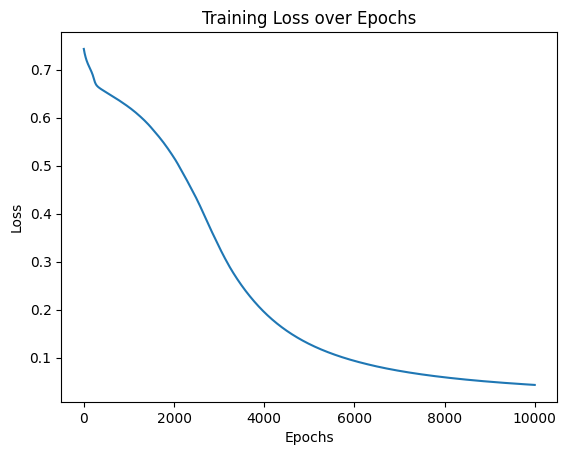

In [23]:
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.set_title("Training Loss over Epochs")
plt.show()

In [24]:
y_pred_test = forward_pass(X_test, W1, b1, W2, b2)
y_pred_labels = (y_pred_test > 0.5).float()
accuracy = (y_pred_labels == y_test).float().mean()
print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

y_pred_train = forward_pass(X_train, W1, b1, W2, b2)
y_pred_labels = (y_pred_train > 0.5).float()
accuracy = (y_pred_labels == y_train).float().mean()
print(f"Train Accuracy: {accuracy.item() * 100:.2f}%")

Test Accuracy: 100.00%
Train Accuracy: 100.00%


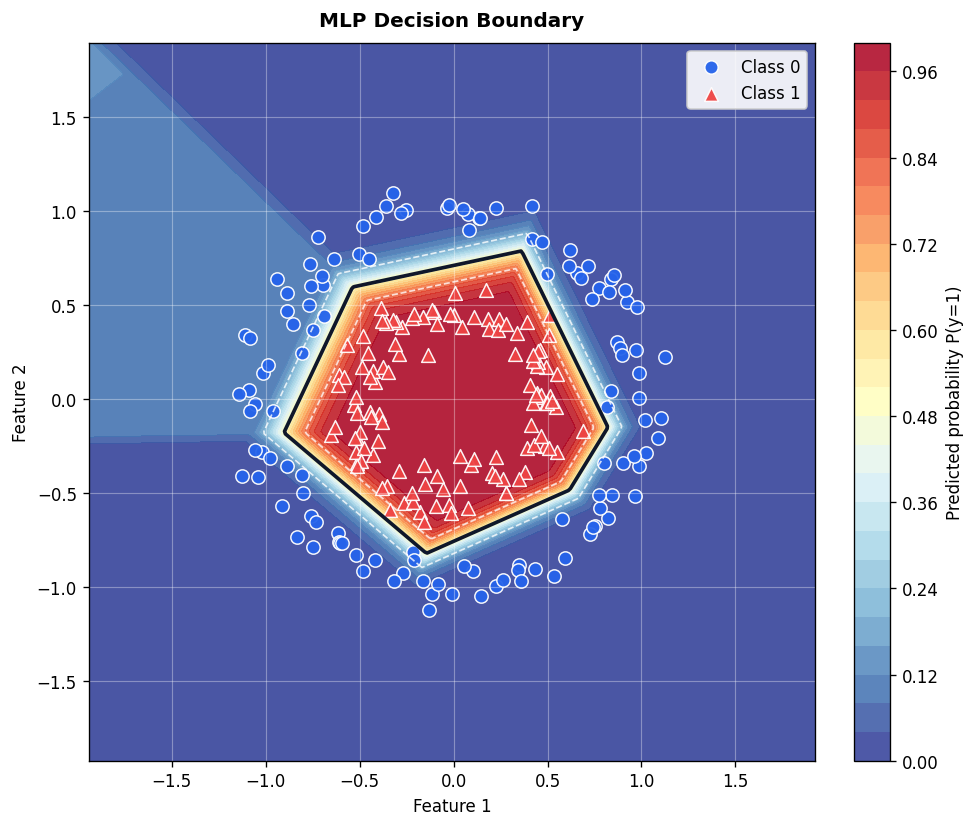

<Axes: title={'center': 'MLP Decision Boundary'}, xlabel='Feature 1', ylabel='Feature 2'>

In [25]:
plot_decision_boundary(X_train, y_train, W1, b1, W2, b2)

## Mini-batch Gradient Descent
In practice, it is often more efficient to use mini-batch gradient descent instead of updating the parameters after every single sample (stochastic gradient descent) or after the entire dataset (batch gradient descent). Mini-batch gradient descent updates the parameters after computing the gradients on a small batch of samples, which can lead to faster convergence and better generalization. To implement mini-batch gradient descent, you can modify the training loop to iterate over batches of data instead of the entire dataset.


#### Exercise:
Modify the training loop to implement mini-batch gradient descent. You can use a batch size of your choice (e.g., 32 or 64) and iterate over the training data in batches during each epoch. Make sure to compute the loss and perform backpropagation for each batch, and update the parameters accordingly.

Your training function should now receive an additional argument for the batch size.

In [26]:
def train_minibatch(X_train, y_train, W1, b1, W2, b2, batch_size=32, epochs=1000, learning_rate=0.01):
    """
    Train the model using mini-batch gradient descent.

    Data is shuffled each epoch. Only full batches are used
    (`n_samples // batch_size`), so any remainder is ignored.

    Args:
        X_train (torch.Tensor): Training inputs.
        y_train (torch.Tensor): Training labels.
        W1 (torch.Tensor): First-layer weights.
        b1 (torch.Tensor): First-layer bias.
        W2 (torch.Tensor): Second-layer weights.
        b2 (torch.Tensor): Second-layer bias.
        batch_size (int, optional): Mini-batch size. Defaults to 32.
        epochs (int, optional): Number of epochs. Defaults to 1000.
        learning_rate (float, optional): Gradient descent step size. Defaults to 0.01.

    Returns:
        list[float]: Average mini-batch loss per epoch.
    """
    n_samples = X_train.shape[0]
    losses = []
    for epoch in range(epochs):
        # Shuffle the data
        indices = t.randperm(n_samples)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        total_loss = 0
        num_batches = n_samples // batch_size

        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]

            loss = training_step(X_batch, y_batch, W1, b1, W2, b2, learning_rate)
            total_loss += loss

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)
        if (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    return losses


In [27]:
losses = train_minibatch(X_train, y_train, W1, b1, W2, b2, epochs=5000, learning_rate=0.03)

Epoch 500/5000, Loss: 0.0302
Epoch 1000/5000, Loss: 0.0239
Epoch 1500/5000, Loss: 0.0189
Epoch 2000/5000, Loss: 0.0166
Epoch 2500/5000, Loss: 0.0145
Epoch 3000/5000, Loss: 0.0129
Epoch 3500/5000, Loss: 0.0109
Epoch 4000/5000, Loss: 0.0100
Epoch 4500/5000, Loss: 0.0074
Epoch 5000/5000, Loss: 0.0075


In [28]:
y_pred_test = forward_pass(X_test, W1, b1, W2, b2)
y_pred_labels = (y_pred_test > 0.5).float()
accuracy = (y_pred_labels == y_test).float().mean()
print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

y_pred_train = forward_pass(X_train, W1, b1, W2, b2)
y_pred_labels = (y_pred_train > 0.5).float()
accuracy = (y_pred_labels == y_train).float().mean()
print(f"Train Accuracy: {accuracy.item() * 100:.2f}%")

Test Accuracy: 100.00%
Train Accuracy: 100.00%


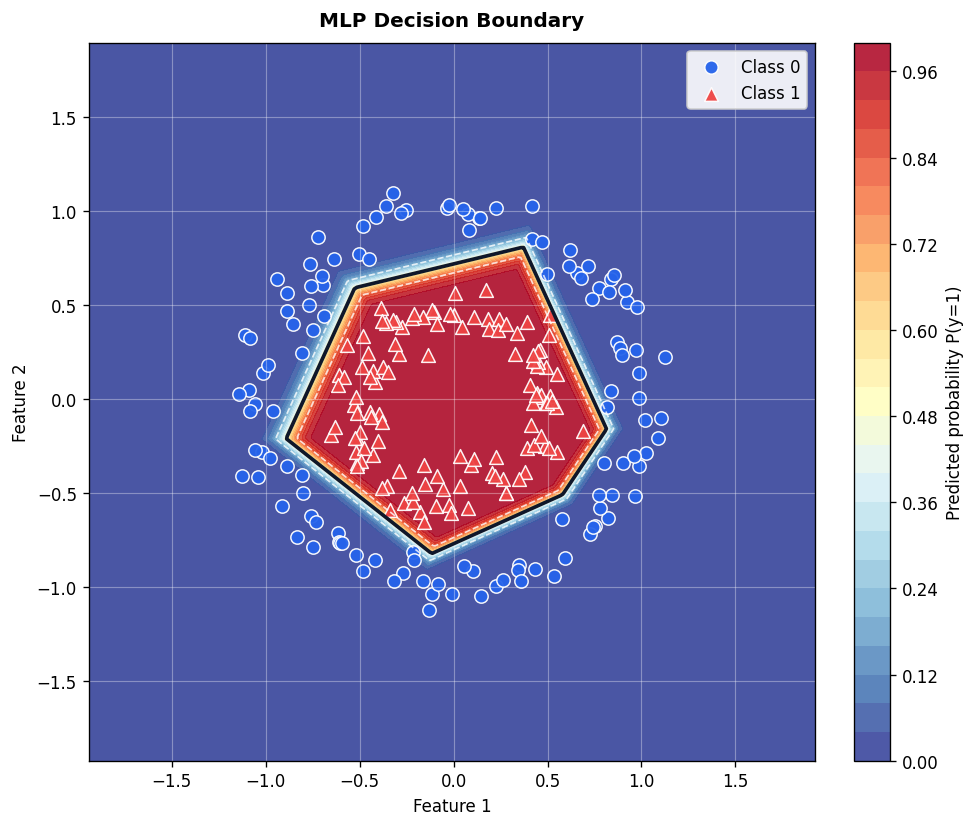

<Axes: title={'center': 'MLP Decision Boundary'}, xlabel='Feature 1', ylabel='Feature 2'>

In [29]:
plot_decision_boundary(X_train, y_train, W1, b1, W2, b2)

#### Advantages of Mini-batch Gradient Descent:
- Faster convergence: Mini-batch gradient descent can converge faster than batch gradient descent because it updates the parameters more frequently, which can lead to quicker adjustments in the direction of the optimal parameters.
- Better generalization: Mini-batch gradient descent can help the model generalize better to unseen data by introducing some noise into the parameter updates, which can help escape local minima and find better solutions.

#### Stochastic Gradient Descent (SGD):
Stochastic Gradient Descent is a special case of mini-batch gradient descent where the batch size is set to 1. This means that the parameters are updated after computing the gradients for each individual sample. While SGD can be noisy and may not converge as smoothly as mini-batch gradient descent, it can be useful for certain applications and can help the model escape local minima. However, in practice, mini-batch gradient descent is often preferred over SGD due to its balance between convergence speed and stability.

#### Exercise:
Try solving the XOR problem using full-batch gradient descent and mini-batch gradient descent. Compare the convergence and performance of the model using these different optimization algorithms.

**Note**: You will have to create a different set of weights and biases for each optimization algorithm.

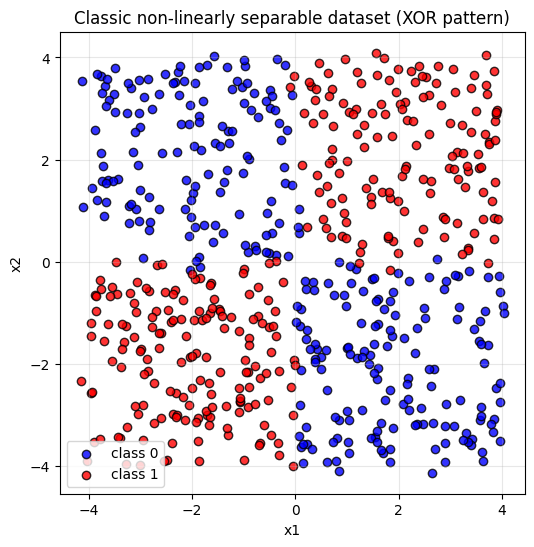

In [30]:
N = 600
test_size = int(N * 0.2)

X_nl = np.random.rand(N, 2) * 8 - 4  # Uniform in [-4, 4]
y_nl = ((X_nl[:, 0] >= 0) & (X_nl[:, 1] >= 0)) | ((X_nl[:, 0] < 0) & (X_nl[:, 1] < 0)) # Class 1 in top-right and bottom-left quadrants, class 0 elsewhere
X_nl = X_nl + np.random.randn(N, 2) * 0.1  # Add some noise
X_nl = t.tensor(X_nl, dtype=t.float32)
y_nl = t.tensor(y_nl, dtype=t.float32).unsqueeze(1)

X_train, X_test = X_nl[test_size:], X_nl[:test_size]
y_train, y_test = y_nl[test_size:], y_nl[:test_size]


plt.figure(figsize=(6,6))
plt.scatter(X_nl[y_nl[:, 0]==0,0], X_nl[y_nl[:, 0]==0,1], color='blue', label='class 0', edgecolor='k', alpha=0.8)
plt.scatter(X_nl[y_nl[:, 0]==1,0], X_nl[y_nl[:, 0]==1,1], color='red', label='class 1', edgecolor='k', alpha=0.8)
plt.title('Classic non-linearly separable dataset (XOR pattern)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

In [31]:
W1, b1 = initilize_weights_and_biases_xavier(INPUT_SIZE, HIDDEN_SIZE)
W2, b2 = initilize_weights_and_biases_xavier(HIDDEN_SIZE, OUTPUT_SIZE)

W1_mb, b1_mb = initilize_weights_and_biases_xavier(INPUT_SIZE, HIDDEN_SIZE)
W2_mb, b2_mb = initilize_weights_and_biases_xavier(HIDDEN_SIZE, OUTPUT_SIZE)

Epoch 500/5000, Loss: 0.0680
Epoch 1000/5000, Loss: 0.0570
Epoch 1500/5000, Loss: 0.0529
Epoch 2000/5000, Loss: 0.0508
Epoch 2500/5000, Loss: 0.0495
Epoch 3000/5000, Loss: 0.0487
Epoch 3500/5000, Loss: 0.0478
Epoch 4000/5000, Loss: 0.0477
Epoch 4500/5000, Loss: 0.0469
Epoch 5000/5000, Loss: 0.0468


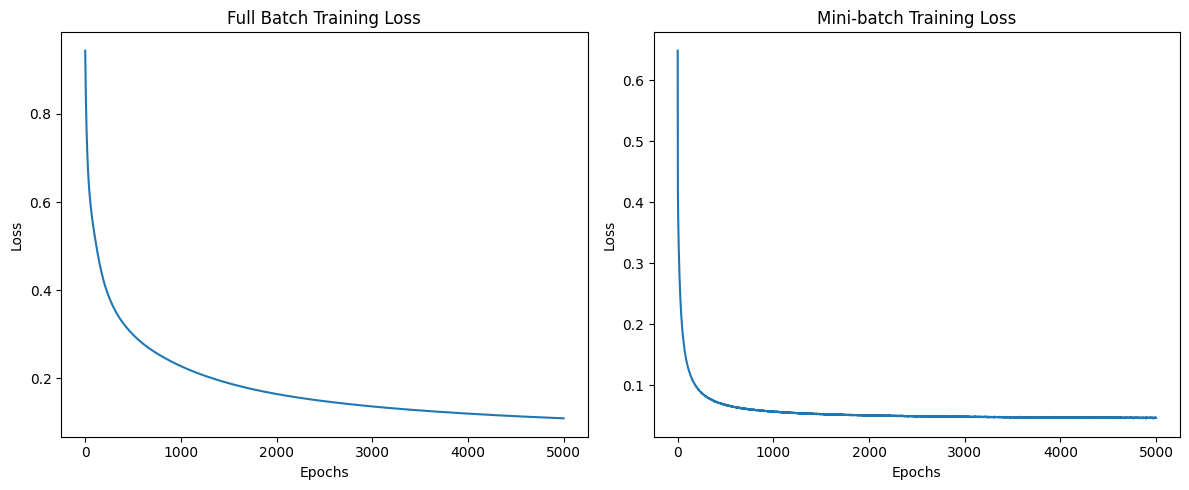

In [32]:
losses = train(X_train, y_train, W1, b1, W2, b2, epochs=5000, learning_rate=0.03)
losses_mb = train_minibatch(X_train, y_train, W1_mb, b1_mb, W2_mb, b2_mb, epochs=5000, learning_rate=0.03)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(losses)
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].set_title("Full Batch Training Loss")


ax[1].plot(losses_mb)
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
ax[1].set_title("Mini-batch Training Loss")
plt.tight_layout()
plt.show()

In [33]:
print("Full Batch Gradient Descent:")
y_pred_test = forward_pass(X_test, W1, b1, W2, b2)
y_pred_labels = (y_pred_test > 0.5).float()
accuracy = (y_pred_labels == y_test).float().mean()
print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

y_pred_train = forward_pass(X_train, W1, b1, W2, b2)
y_pred_labels = (y_pred_train > 0.5).float()
accuracy = (y_pred_labels == y_train).float().mean()
print(f"Train Accuracy: {accuracy.item() * 100:.2f}%")

print("Mini-batch Gradient Descent:")
y_pred_test = forward_pass(X_test, W1_mb, b1_mb, W2_mb, b2_mb)
y_pred_labels = (y_pred_test > 0.5).float()
accuracy = (y_pred_labels == y_test).float().mean()
print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

y_pred_train = forward_pass(X_train, W1_mb, b1_mb, W2_mb, b2_mb)
y_pred_labels = (y_pred_train > 0.5).float()
accuracy = (y_pred_labels == y_train).float().mean()
print(f"Train Accuracy: {accuracy.item() * 100:.2f}%")

Full Batch Gradient Descent:
Test Accuracy: 97.50%
Train Accuracy: 96.25%
Mini-batch Gradient Descent:
Test Accuracy: 99.17%
Train Accuracy: 98.33%


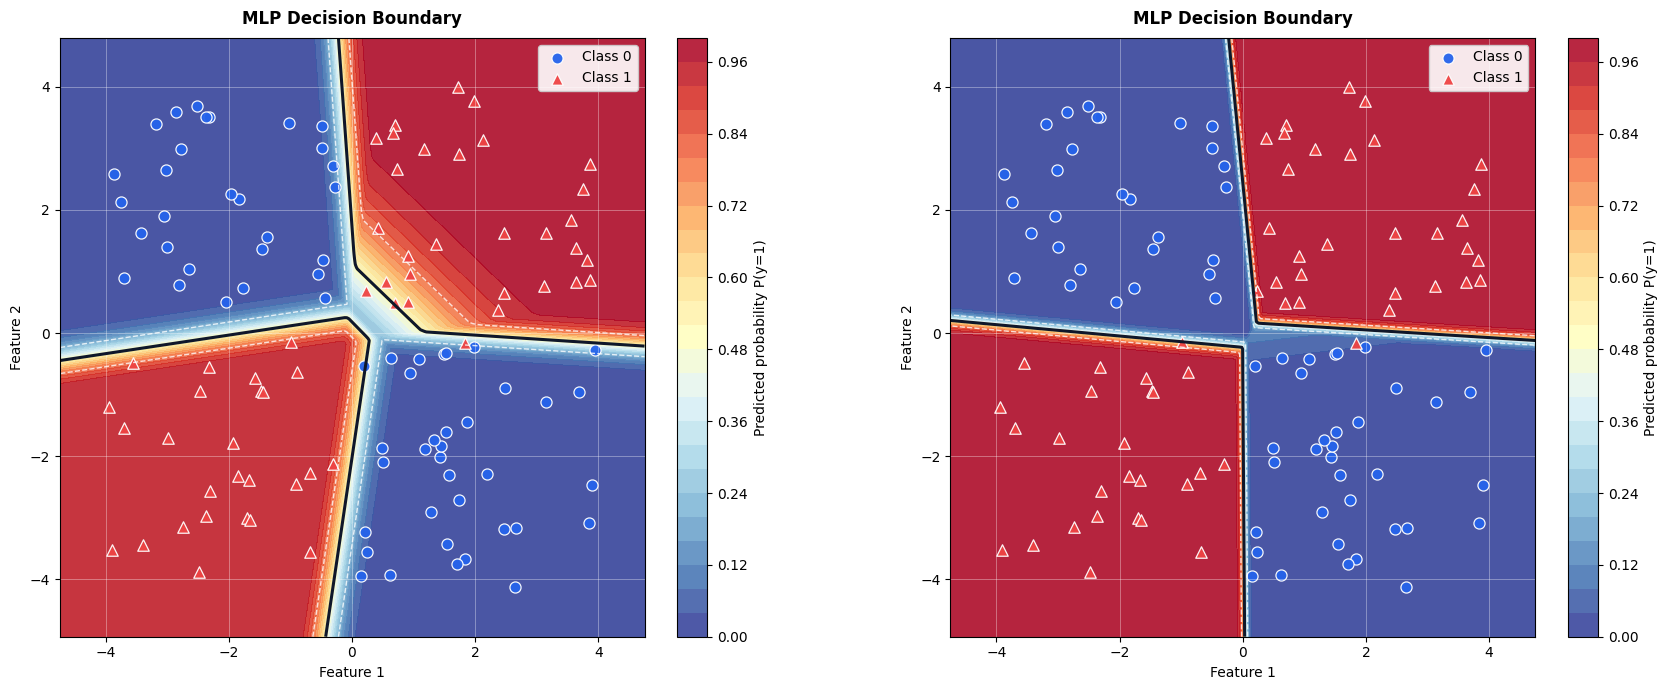

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

plot_decision_boundary(X_test, y_test, W1, b1, W2, b2, ax=ax[0])
plot_decision_boundary(X_test, y_test, W1_mb, b1_mb, W2_mb, b2_mb, ax=ax[1])

plt.tight_layout()